# Physics-Informed Neural Networks (PINNs)

## Solving the 1D Heat Equation

### Objective

The objective of this notebook is to solve the one-dimensional Heat Equation using a Physics-Informed Neural Network (PINN).

Unlike traditional neural networks, a PINN does not rely solely on labeled data. Instead, it incorporates the governing physical equation directly into the training process.

In this notebook, the neural network learns the temperature distribution inside a one-dimensional rod while satisfying:

- The Heat Equation
- Initial Conditions
- Boundary Conditions

By the end of this notebook, we will compare the PINN solution with the exact analytical solution and visualize the temperature evolution over space and time.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

Device : cuda
NVIDIA GeForce RTX 2050


# Problem Statement

We want to solve the one-dimensional Heat Equation

du/dt = α d²u/dx²

where

u(x,t)  → Temperature

x       → Position

t       → Time

α       → Thermal Diffusivity

Instead of using finite difference or finite element methods, we will train a neural network that satisfies the governing physics.

The neural network must satisfy

1. Heat Equation

2. Initial Condition

3. Boundary Conditions

In [4]:
alpha = 0.01
def exact_solution(x, t):

    return np.exp(-(np.pi**2)*alpha*t) * np.sin(np.pi*x)
print(exact_solution(0.5,0))

#sin(pi/2)=1

1.0


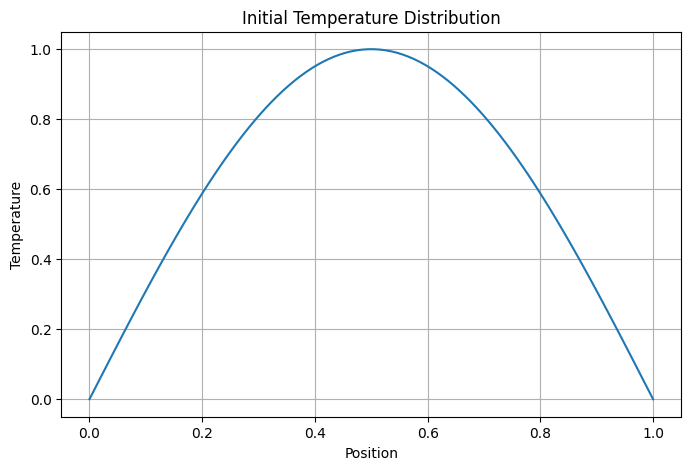

In [5]:
x = np.linspace(0,1,100)

t = 0

u = exact_solution(x,t)

plt.figure(figsize=(8,5))

plt.plot(x,u)

plt.grid(True)

plt.xlabel("Position")

plt.ylabel("Temperature")

plt.title("Initial Temperature Distribution")

plt.show()

# Physics-Informed Neural Network

The neural network represents the unknown temperature function

u(x,t)

Input:
- x → Position
- t → Time

Output:
- u(x,t) → Predicted Temperature

The trainable parameters (weights and biases) are optimized so that the network satisfies:

1. Heat Equation
2. Initial Condition
3. Boundary Conditions

# Visualization
          x
          │
          │
          t
          │
          ▼
     Neural Network
          │
          ▼
       u(x,t)

In [7]:
class PINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(2,32),
            nn.Tanh(),

            nn.Linear(32,32),
            nn.Tanh(),

            nn.Linear(32,32),
            nn.Tanh(),

            nn.Linear(32,1)

        )

    def forward(self, x):

        return self.network(x)

model = PINN().to(device)
print(model)

PINN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [8]:
total_params = sum(p.numel() for p in model.parameters())

print(f"Total Trainable Parameters: {total_params}")

Total Trainable Parameters: 2241


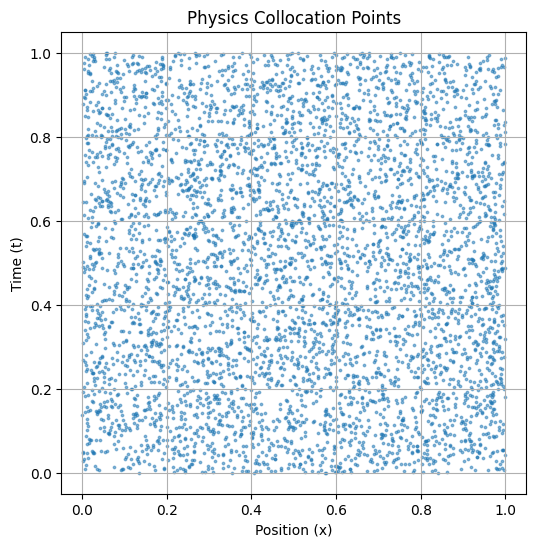

In [10]:
# No of points
N_f = 5000      # Physics (collocation) points
N_ic = 200      # Initial condition points
N_bc = 200      # Boundary condition points

# Physics Points
x_f = torch.rand((N_f, 1), device=device)

t_f = torch.rand((N_f, 1), device=device)

X_f = torch.cat((x_f, t_f), dim=1)

X_f.requires_grad_(True)

# Visual Physiccs Points
plt.figure(figsize=(6,6))

plt.scatter(
    x_f.cpu(),
    t_f.cpu(),
    s=3,
    alpha=0.5
)

plt.xlabel("Position (x)")
plt.ylabel("Time (t)")
plt.title("Physics Collocation Points")

plt.grid(True)

plt.show()

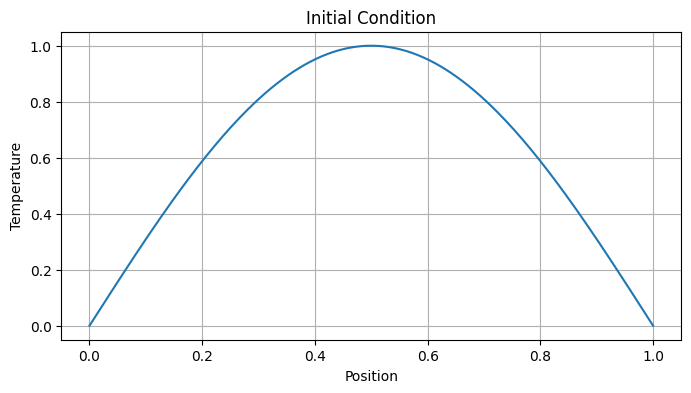

In [11]:
# Initial Condition Points 
x_ic = torch.linspace(0, 1, N_ic).reshape(-1,1).to(device)

t_ic = torch.zeros_like(x_ic)

X_ic = torch.cat((x_ic, t_ic), dim=1)

#Tg values
u_ic = torch.sin(torch.pi * x_ic)

#Plt
plt.figure(figsize=(8,4))

plt.plot(
    x_ic.cpu(),
    u_ic.cpu()
)

plt.xlabel("Position")
plt.ylabel("Temperature")

plt.title("Initial Condition")

plt.grid(True)

plt.show()

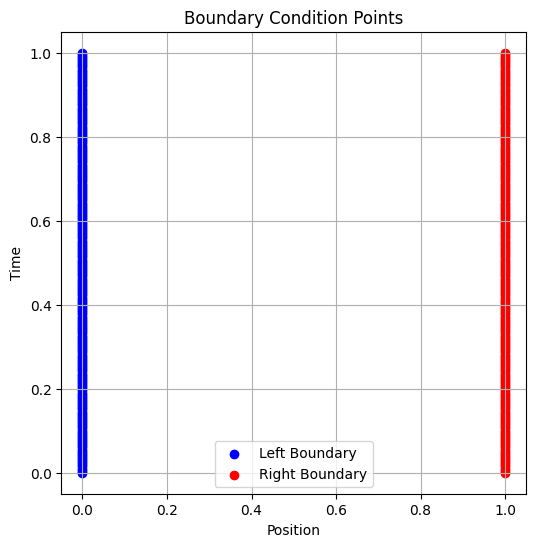

In [12]:
# Boundary Condition Points
# Left
t_bc = torch.linspace(0,1,N_bc).reshape(-1,1).to(device)

x_left = torch.zeros_like(t_bc)

X_left = torch.cat((x_left, t_bc), dim=1)

u_left = torch.zeros_like(t_bc)
# Right
x_right = torch.ones_like(t_bc)

X_right = torch.cat((x_right, t_bc), dim=1)

u_right = torch.zeros_like(t_bc)

#Plt 
plt.figure(figsize=(6,6))

plt.scatter(
    x_left.cpu(),
    t_bc.cpu(),
    color="blue",
    label="Left Boundary"
)

plt.scatter(
    x_right.cpu(),
    t_bc.cpu(),
    color="red",
    label="Right Boundary"
)

plt.xlabel("Position")

plt.ylabel("Time")

plt.title("Boundary Condition Points")

plt.legend()

plt.grid(True)

plt.show()

# Forward Pass and Automatic Differentiation

The collocation points are passed through the neural network to obtain the predicted temperature.

Using PyTorch's Automatic Differentiation (AutoGrad), we compute:

- First derivative with respect to space (∂u/∂x)
- First derivative with respect to time (∂u/∂t)
- Second derivative with respect to space (∂²u/∂x²)

These derivatives are required to evaluate the Heat Equation residual.

In [13]:
u_f = model(X_f)
print(u_f.shape)

torch.Size([5000, 1])


In [15]:
grads = torch.autograd.grad(

    outputs=u_f,

    inputs=X_f,

    grad_outputs=torch.ones_like(u_f),

    create_graph=True

)[0]

u_x = grads[:,0:1]

u_t = grads[:,1:2]

print(u_x.shape)

print(u_t.shape)

torch.Size([5000, 1])
torch.Size([5000, 1])


In [17]:
grads2 = torch.autograd.grad(

    outputs=u_x,

    inputs=X_f,

    grad_outputs=torch.ones_like(u_x),

    create_graph=True

)[0]

u_xx = grads2[:,0:1]

print(u_xx.shape)

torch.Size([5000, 1])


In [18]:
residual = u_t - alpha*u_xx

#PL
physics_loss = torch.mean(residual**2)

print(f"Physics Loss : {physics_loss.item():.6f}")

Physics Loss : 0.000056


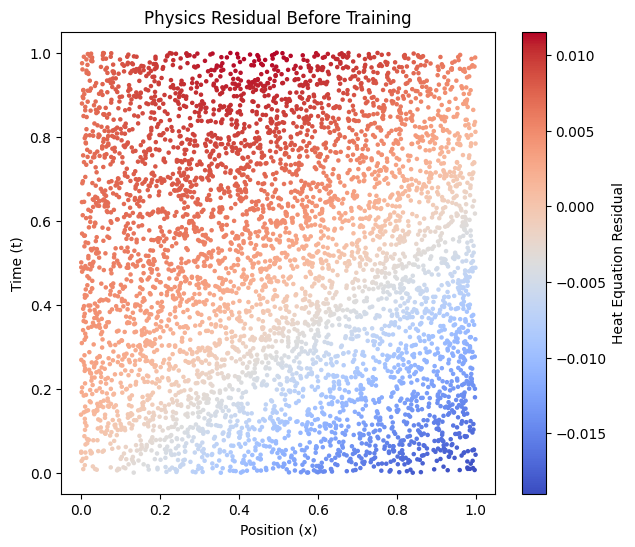

In [19]:
plt.figure(figsize=(7,6))

plt.scatter(

    x_f.detach().cpu(),

    t_f.detach().cpu(),

    c=residual.detach().cpu(),

    s=5,

    cmap="coolwarm"

)

plt.colorbar(label="Heat Equation Residual")

plt.xlabel("Position (x)")

plt.ylabel("Time (t)")

plt.title("Physics Residual Before Training")

plt.show()

# Initial Condition, Boundary Condition and Total Loss

The Heat Equation alone does not uniquely determine the solution.

To obtain the physically correct temperature distribution, the neural network must also satisfy:

1. Initial Condition
2. Boundary Conditions

The total loss is computed as

Total Loss = Physics Loss + Initial Condition Loss + Boundary Condition Loss

Minimizing the total loss forces the network to satisfy both the governing physics and the known constraints.

In [26]:
u_ic_pred = model(X_ic)

u_ic = torch.sin(torch.pi * x_ic)

ic_loss = torch.mean((u_ic_pred - u_ic)**2)

u_left_pred = model(X_left)

left_bc_loss = torch.mean((u_left_pred - u_left)**2)

u_right_pred = model(X_right)

right_bc_loss = torch.mean((u_right_pred - u_right)**2)

bc_loss = left_bc_loss + right_bc_loss

print(f"Initial Condition Loss : {ic_loss.item():.6f}")

print(f"Boundary Loss : {bc_loss.item():.6f}")

Initial Condition Loss : 0.707353
Boundary Loss : 0.041558


In [27]:
total_loss = physics_loss + ic_loss + bc_loss
print(f"Physics Loss          : {physics_loss.item():.6f}")
print(f"Initial Condition     : {ic_loss.item():.6f}")
print(f"Boundary Condition    : {bc_loss.item():.6f}")
print("-"*40)
print(f"Total Loss            : {total_loss.item():.6f}")

Physics Loss          : 0.000056
Initial Condition     : 0.707353
Boundary Condition    : 0.041558
----------------------------------------
Total Loss            : 0.748967


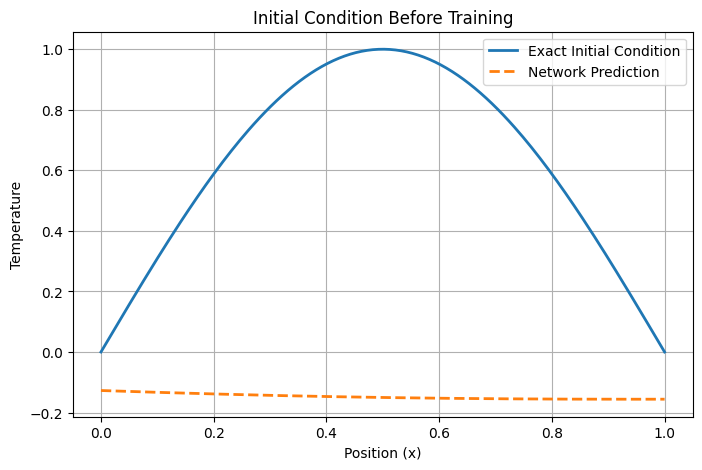

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    x_ic.cpu(),
    u_ic.cpu(),
    linewidth=2,
    label="Exact Initial Condition"
)

plt.plot(
    x_ic.cpu(),
    u_ic_pred.detach().cpu(),
    "--",
    linewidth=2,
    label="Network Prediction"
)

plt.xlabel("Position (x)")
plt.ylabel("Temperature")
plt.title("Initial Condition Before Training")

plt.grid(True)
plt.legend()

plt.show()

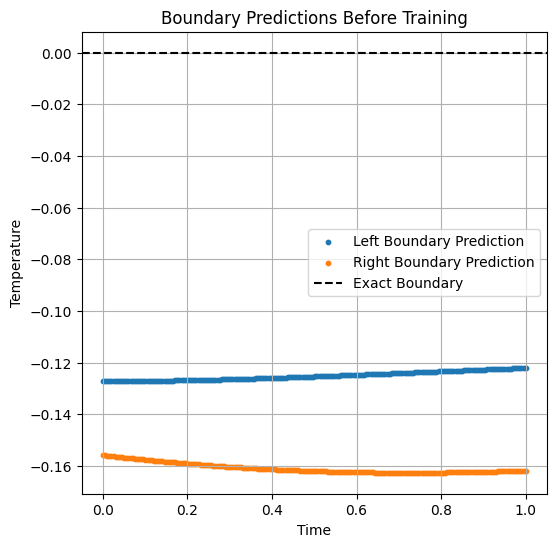

In [29]:
plt.figure(figsize=(6,6))

plt.scatter(
    t_bc.cpu(),
    u_left_pred.detach().cpu(),
    s=10,
    label="Left Boundary Prediction"
)

plt.scatter(
    t_bc.cpu(),
    u_right_pred.detach().cpu(),
    s=10,
    label="Right Boundary Prediction"
)

plt.axhline(0,color="black",linestyle="--",label="Exact Boundary")

plt.xlabel("Time")
plt.ylabel("Temperature")

plt.title("Boundary Predictions Before Training")

plt.legend()
plt.grid(True)

plt.show()

# Training the PINN

During training, the neural network repeatedly:

1. Predicts the temperature field.
2. Computes the required derivatives using AutoGrad.
3. Evaluates the Heat Equation residual.
4. Computes the Physics Loss.
5. Computes the Initial Condition Loss.
6. Computes the Boundary Condition Loss.
7. Combines all losses into the Total Loss.
8. Updates the network parameters using backpropagation.

This process is repeated for multiple epochs until the network learns the correct temperature distribution.

In [32]:
# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Number of training epochs
epochs = 5000

# Store losses
total_loss_history = []
physics_loss_history = []
ic_loss_history = []
bc_loss_history = []

# Training loop
for epoch in range(epochs):

    # Reset gradients
    optimizer.zero_grad()

    # Physics Points

    u_f = model(X_f)

    grads = torch.autograd.grad(
        outputs=u_f,
        inputs=X_f,
        grad_outputs=torch.ones_like(u_f),
        create_graph=True
    )[0]

    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]

    grads2 = torch.autograd.grad(
        outputs=u_x,
        inputs=X_f,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_xx = grads2[:, 0:1]

    # Heat Equation Residual
    residual = u_t - alpha * u_xx

    # Physics Loss
    physics_loss = torch.mean(residual ** 2)
    
    # Initial Condition

    u_ic_pred = model(X_ic)

    ic_loss = torch.mean(
        (u_ic_pred - u_ic) ** 2
    )

    # Boundary Conditions

    u_left_pred = model(X_left)

    left_bc_loss = torch.mean(
        (u_left_pred - u_left) ** 2
    )

    u_right_pred = model(X_right)

    right_bc_loss = torch.mean(
        (u_right_pred - u_right) ** 2
    )

    bc_loss = left_bc_loss + right_bc_loss

    # Total Loss

    total_loss = (
        physics_loss
        + ic_loss
        + bc_loss
    )

    # Backpropagation

    total_loss.backward()

    optimizer.step()

    # Store Losses

    total_loss_history.append(total_loss.item())
    physics_loss_history.append(physics_loss.item())
    ic_loss_history.append(ic_loss.item())
    bc_loss_history.append(bc_loss.item())

    # Progress

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Physics: {physics_loss.item():.6f} | "
            f"IC: {ic_loss.item():.6f} | "
            f"BC: {bc_loss.item():.6f} | "
            f"Total: {total_loss.item():.6f}"
        )

Epoch     0 | Physics: 0.000004 | IC: 0.000000 | BC: 0.000001 | Total: 0.000006
Epoch   500 | Physics: 0.000004 | IC: 0.000000 | BC: 0.000000 | Total: 0.000005
Epoch  1000 | Physics: 0.000004 | IC: 0.000000 | BC: 0.000000 | Total: 0.000004
Epoch  1500 | Physics: 0.000003 | IC: 0.000000 | BC: 0.000000 | Total: 0.000003
Epoch  2000 | Physics: 0.000003 | IC: 0.000000 | BC: 0.000000 | Total: 0.000003
Epoch  2500 | Physics: 0.000002 | IC: 0.000000 | BC: 0.000000 | Total: 0.000003
Epoch  3000 | Physics: 0.000002 | IC: 0.000000 | BC: 0.000000 | Total: 0.000002
Epoch  3500 | Physics: 0.000002 | IC: 0.000020 | BC: 0.000035 | Total: 0.000058
Epoch  4000 | Physics: 0.000002 | IC: 0.000000 | BC: 0.000000 | Total: 0.000002
Epoch  4500 | Physics: 0.000002 | IC: 0.000000 | BC: 0.000000 | Total: 0.000002


# Evaluation

After training, the PINN is evaluated on a dense space-time grid.

The learned solution is compared with the exact analytical solution.

The following visualizations are generated:

- Loss Curves
- Temperature Heatmap
- Exact Solution
- PINN Prediction
- Error Heatmap
- Time Slice Comparisons
- 3D Surface Plot

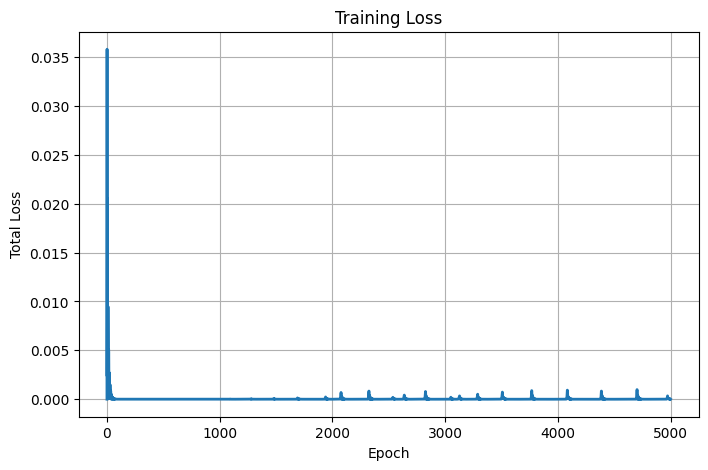

In [36]:
# Evaluation Grid

x_eval = torch.linspace(0, 1, 100)
t_eval = torch.linspace(0, 1, 100)

X, T = torch.meshgrid(
    x_eval,
    t_eval,
    indexing="ij"
)

X_test = torch.cat(

    (
        X.reshape(-1,1),
        T.reshape(-1,1)
    ),

    dim=1

).to(device)

# Network Prediction
model.eval()

with torch.no_grad():

    u_pred = model(X_test)
u_pred = u_pred.cpu().numpy().reshape(100,100)

#Exact Solution
u_exact = exact_solution(

    X.cpu().numpy(),

    T.cpu().numpy()

)
# Total Loss Curve
plt.figure(figsize=(8,5))

plt.plot(
    total_loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss")
plt.grid(True)

plt.show()

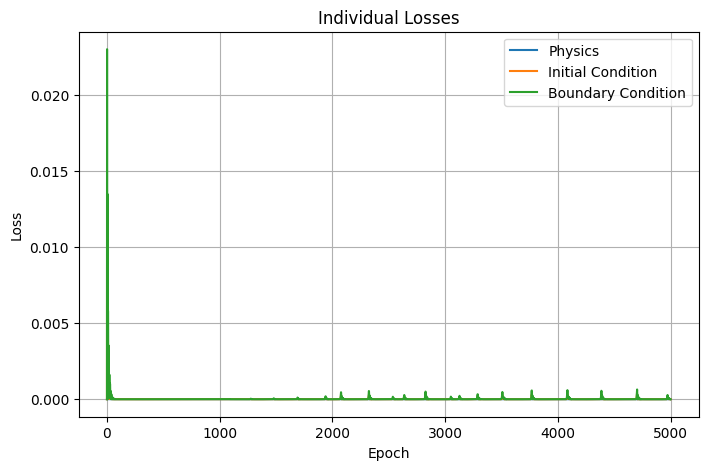

In [35]:
# Individual Losses
plt.figure(figsize=(8,5))

plt.plot(
    physics_loss_history,
    label="Physics"
)

plt.plot(
    ic_loss_history,
    label="Initial Condition"
)

plt.plot(
    bc_loss_history,
    label="Boundary Condition"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Individual Losses")

plt.legend()

plt.grid(True)

plt.show()

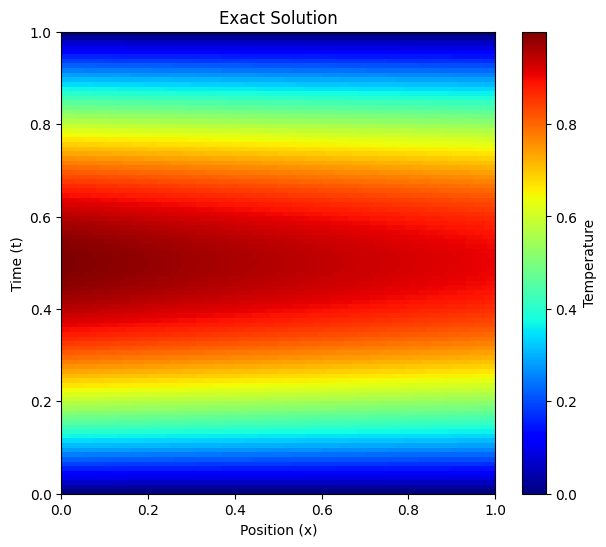

In [42]:
# Exact Solution Heatmap
plt.figure(figsize=(7,6))

plt.imshow(

    u_exact,

    extent=[0,1,0,1],

    origin="lower",

    aspect="auto",

    cmap="jet"

)

plt.colorbar(label="Temperature")

plt.xlabel("Position (x)")

plt.ylabel("Time (t)")

plt.title("Exact Solution")

plt.show()

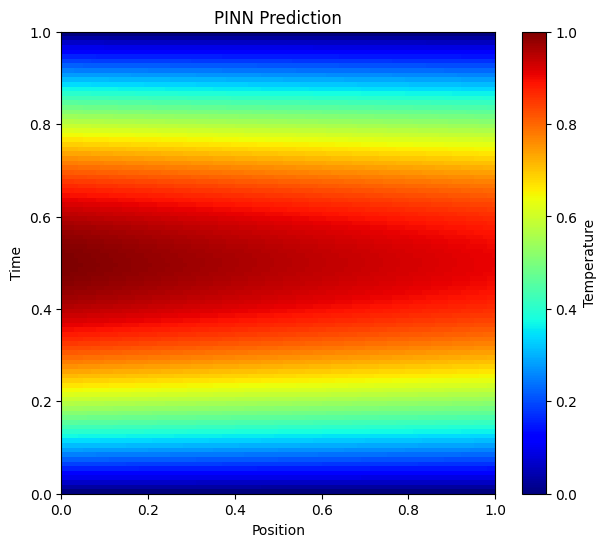

In [38]:
# PINN Prediction
plt.figure(figsize=(7,6))

plt.imshow(

    u_pred,

    extent=[0,1,0,1],

    origin="lower",

    aspect="auto",

    cmap="jet"

)

plt.colorbar(label="Temperature")

plt.xlabel("Position")

plt.ylabel("Time")

plt.title("PINN Prediction")

plt.show()

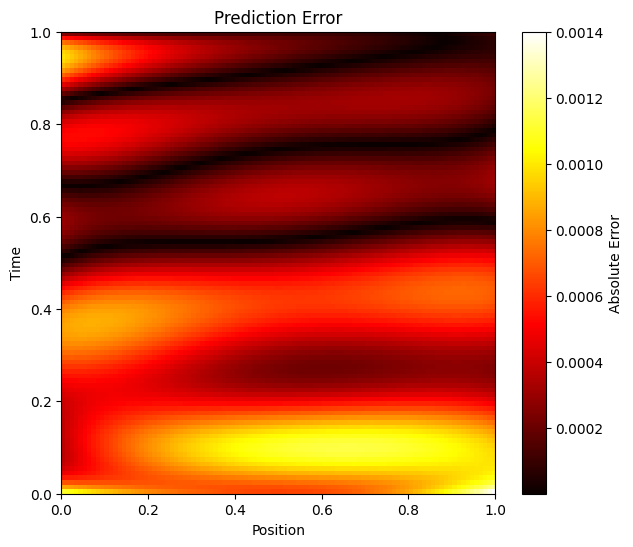

In [39]:
# Error Heatmap
error = np.abs(

    u_exact-u_pred

)
plt.figure(figsize=(7,6))

plt.imshow(

    error,

    extent=[0,1,0,1],

    origin="lower",

    aspect="auto",

    cmap="hot"

)

plt.colorbar(label="Absolute Error")

plt.xlabel("Position")

plt.ylabel("Time")

plt.title("Prediction Error")

plt.show()

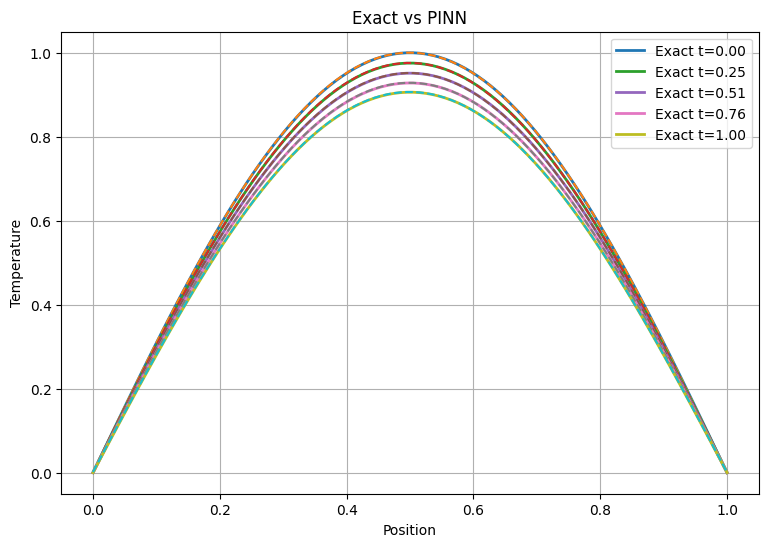

In [40]:
# Time Slice Comparison
t=0.5

times = [0,25,50,75,99]

plt.figure(figsize=(9,6))

for idx in times:

    plt.plot(

        x_eval.numpy(),

        u_exact[:,idx],

        linewidth=2,

        label=f"Exact t={idx/99:.2f}"

    )

    plt.plot(

        x_eval.numpy(),

        u_pred[:,idx],

        "--"

    )

plt.xlabel("Position")

plt.ylabel("Temperature")

plt.title("Exact vs PINN")

plt.grid(True)

plt.legend()

plt.show()

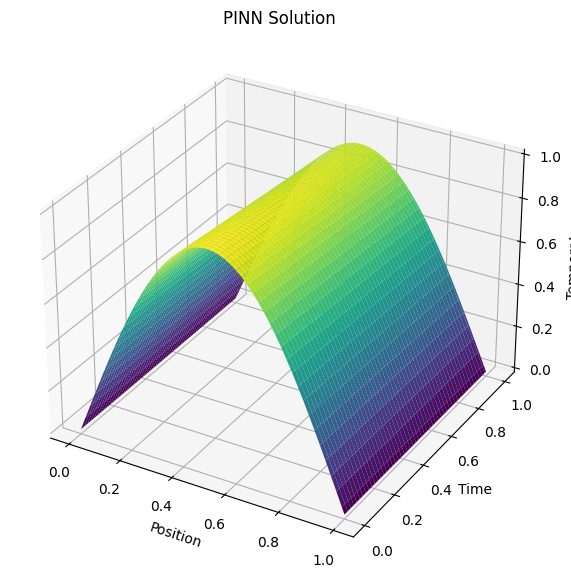

In [41]:
# 3d Surface
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot_surface(

    X.numpy(),

    T.numpy(),

    u_pred,

    cmap="viridis"

)

ax.set_xlabel("Position")

ax.set_ylabel("Time")

ax.set_zlabel("Temperature")

ax.set_title("PINN Solution")

plt.show()

# Conclusions

The PINN successfully learned the one-dimensional Heat Equation.

The governing physics was enforced using the PDE residual, while the initial and boundary conditions constrained the network to the unique physical solution.

The predicted solution closely matched the analytical solution, demonstrating that Physics-Informed Neural Networks can solve differential equations without relying on large labeled datasets.

Key concepts learned:

- Automatic Differentiation
- Physics Residual
- Initial Conditions
- Boundary Conditions
- Total Loss
- PDE-Constrained Optimization